In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot as plt
import seaborn as sns


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cars-pre/car_price_prediction_.csv


In [2]:
df=pd.read_csv('/kaggle/input/cars-pre/car_price_prediction_.csv')

In [3]:
df.sample(7)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
184,185,Tesla,2009,4.0,Hybrid,Manual,205538,Used,78390.81,Model Y
1458,1459,Ford,2002,4.7,Electric,Automatic,61009,New,66947.85,Mustang
2238,2239,Toyota,2023,3.4,Hybrid,Manual,111186,Like New,61088.35,Corolla
1312,1313,Ford,2009,1.3,Hybrid,Automatic,110234,New,71141.91,Explorer
2342,2343,Ford,2016,4.4,Diesel,Manual,15457,Like New,45414.47,Explorer
1635,1636,Honda,2020,4.0,Hybrid,Manual,206089,Like New,92815.34,Fit
1318,1319,Honda,2013,5.8,Hybrid,Automatic,216461,New,31373.19,Civic


In [4]:
df.columns=df.columns.str.lower().str.strip().str.replace(' ','_')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car_id        2500 non-null   int64  
 1   brand         2500 non-null   object 
 2   year          2500 non-null   int64  
 3   engine_size   2500 non-null   float64
 4   fuel_type     2500 non-null   object 
 5   transmission  2500 non-null   object 
 6   mileage       2500 non-null   int64  
 7   condition     2500 non-null   object 
 8   price         2500 non-null   float64
 9   model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [6]:
df.duplicated().sum()

0

In [7]:
df.brand.value_counts()

brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64

Almost Every brand have same number of cars . There is no dominating brand within the dataset , so there is no need of any type of sampling 

In [8]:
print(f"Unique values of Condition {df.condition.unique()}")
print(f"Unique values of Fuel {df.fuel_type.unique()}")
print(f"Unique values of Brand {df.brand.unique()}")

Unique values of Condition ['New' 'Used' 'Like New']
Unique values of Fuel ['Petrol' 'Electric' 'Diesel' 'Hybrid']
Unique values of Brand ['Tesla' 'BMW' 'Audi' 'Ford' 'Honda' 'Mercedes' 'Toyota']


In [9]:
df[['engine_size','mileage','price']].describe()

,engine_size,mileage,price
count,2500.000000,2500.000000,2500.000000
mean,3.465240,149749.844800,52638.022532
std,1.432053,87919.952034,27295.833455
min,1.000000,15.000000,5011.270000
25%,2.200000,71831.500000,28908.485000
50%,3.400000,149085.000000,53485.240000
75%,4.700000,225990.500000,75838.532500
max,6.000000,299967.000000,99982.590000


According to above metric, Mileage columns is left skewwed . There are lots of outliers present in it , Although this columns doesn't make any sense logically . An mileage of an vehicle is just the average distance an vechicle can travel (km) per unit of litre . Since it is synthethically driven data the mileage can get outdoored if it doesn't contribute towards the target column.

Conclusion :- Data is cleaned and well-maintained except Mileage attribute. There is no such an missing value or duplicate values detected. Data is consistent too , there is no duplicated representation of same entity. But only it lacks in validation.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


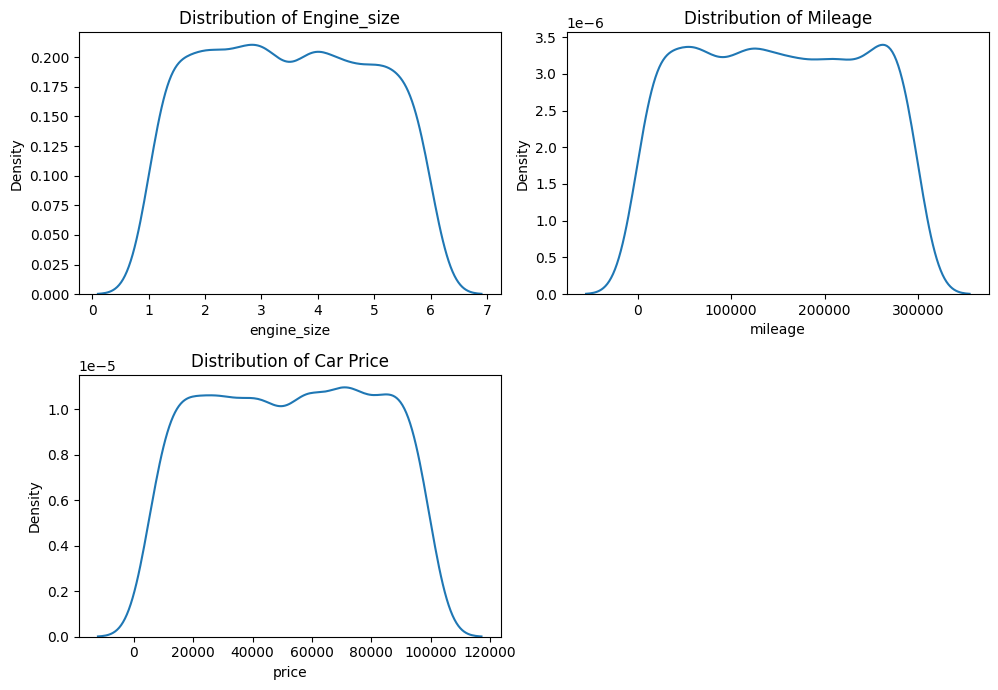

In [10]:
# Exploratory Data Analysis

# Univariate Analysis 
plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
sns.kdeplot(df.engine_size)
plt.title("Distribution of Engine_size")

plt.subplot(2,2,2)
sns.kdeplot(df.mileage)
plt.title("Distribution of Mileage")

plt.subplot(2,2,3)
sns.kdeplot(df.price)
plt.title("Distribution of Car Price")

plt.tight_layout()
plt.show()

All Numerical columns follow up the same distribution which is not exactly normal but some - how close to Gausian Distribution .

Engine_size skewness :- 0.04 <br>
Mileage skewness :- 0.01 <br>
Price skewness :- -0.01 <br>


<b> Note :- close to zero means close to normality </b>


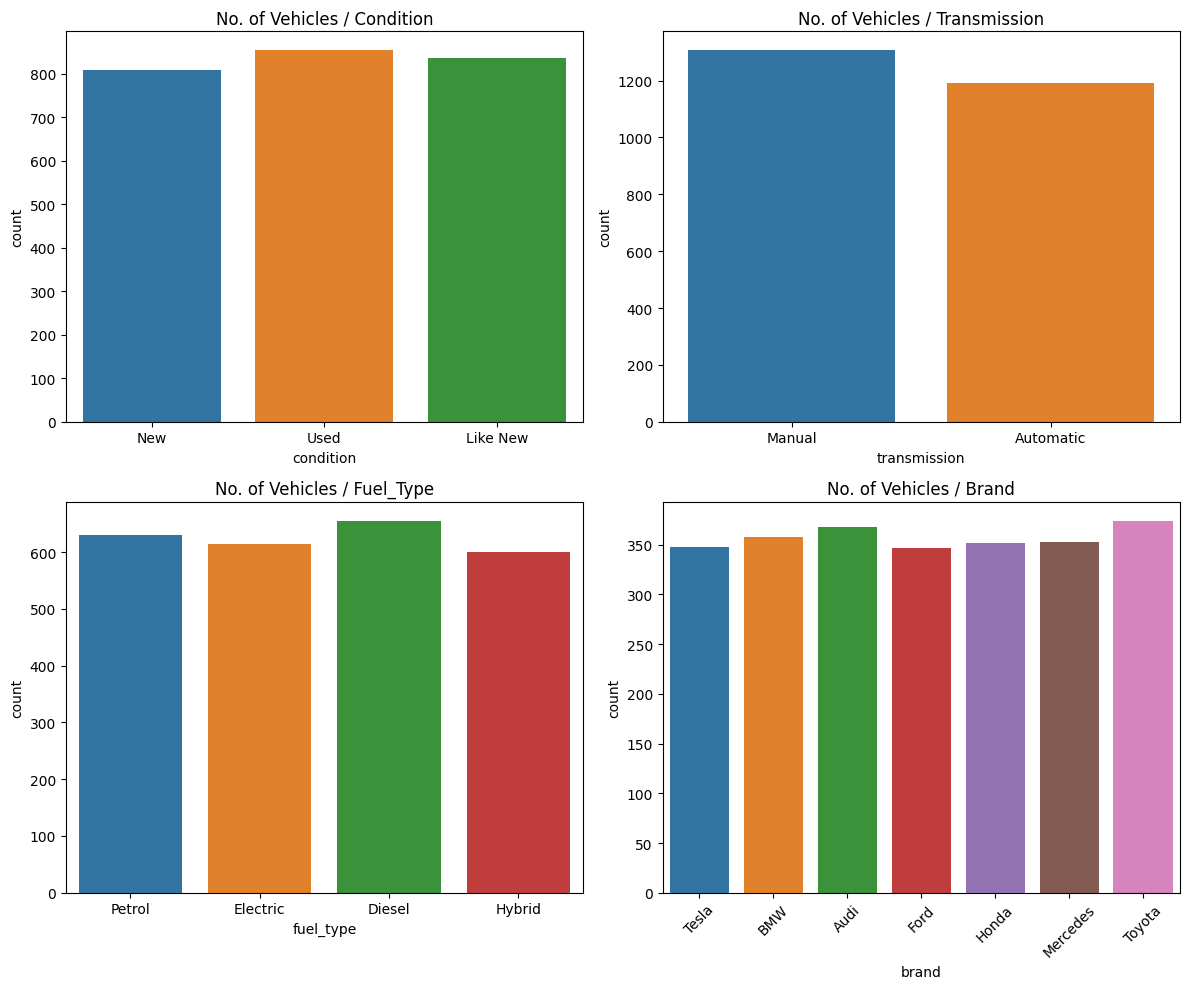

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

sns.countplot(data=df, x='condition', ax=axes[0])
axes[0].set_title("No. of Vehicles / Condition")

sns.countplot(data=df, x='transmission', ax=axes[1])
axes[1].set_title("No. of Vehicles / Transmission")

sns.countplot(data=df, x='fuel_type', ax=axes[2])
axes[2].set_title("No. of Vehicles / Fuel_Type")

sns.countplot(data=df, x='brand', ax=axes[3])
axes[3].set_title("No. of Vehicles / Brand")
plt.xticks(rotation=45)  # optional, rotates x labels for readability
plt.tight_layout()       # adjusts spacing so titles & labels don't overlap
plt.show()

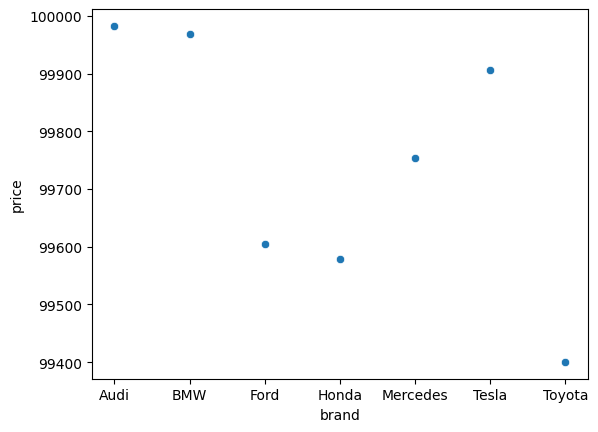

In [12]:
# Bivariate or Multivariate Analysis

sns.scatterplot(x=df.groupby('brand')['price'].max().index, y=df.groupby('brand')['price'].max())
plt.show()



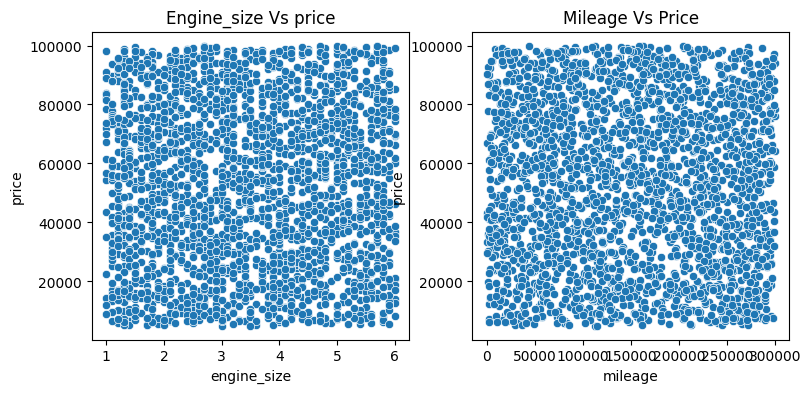

In [13]:
fig,axes=plt.subplots(1,2,figsize=(9,4))
axes=axes.flatten()

sns.scatterplot(x=df.engine_size, y=df.price , ax=axes[0])
axes[0].set_title('Engine_size Vs price')

sns.scatterplot(x=df.mileage, y= df.price, ax=axes[1])
axes[1].set_title('Mileage Vs Price')

plt.show()


In [14]:
# Machine Learning Model Building 

from sklearn.preprocessing import LabelEncoder ,OrdinalEncoder, StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline 


In [15]:
X=df[['brand','year','engine_size','fuel_type','transmission','mileage','condition','model']]
y=df.price

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)

In [16]:
pre = ColumnTransformer([('std',StandardScaler(),['engine_size','mileage']),
                         ('encode',OrdinalEncoder(),['brand','year','fuel_type','transmission','model']),
                        ('endcode1', OrdinalEncoder(categories=[['Used','Like New','New']]),['condition'])])

In [17]:
pipeline=Pipeline([('preprocessing',pre),('model',LinearRegression())])
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('std', StandardScaler(),
                                                  ['engine_size', 'mileage']),
                                                 ('encode', OrdinalEncoder(),
                                                  ['brand', 'year', 'fuel_type',
                                                   'transmission', 'model']),
                                                 ('endcode1',
                                                  OrdinalEncoder(categories=[['Used',
                                                                              'Like '
                                                                              'New',
                                                                              'New']]),
                                                  ['condition'])])),
                ('model', LinearRegression())])

In [18]:
y_pred=pipeline.predict(X_test)

print(f"Mean Absolute Error {mean_absolute_error(y_test,y_pred)}")
print(f"Mean Squared Error {mean_squared_error(y_test,y_pred)}")
print(f"R2 Score {r2_score(y_test,y_pred)}")

Mean Absolute Error 23790.91682626867
Mean Squared Error 758171499.3488514
R2 Score -0.014211383251875986


In [19]:
pipeline1=Pipeline([('preprocessing',pre),('model',DecisionTreeRegressor(max_depth=3))])
pipeline1.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('std', StandardScaler(),
                                                  ['engine_size', 'mileage']),
                                                 ('encode', OrdinalEncoder(),
                                                  ['brand', 'year', 'fuel_type',
                                                   'transmission', 'model']),
                                                 ('endcode1',
                                                  OrdinalEncoder(categories=[['Used',
                                                                              'Like '
                                                                              'New',
                                                                              'New']]),
                                                  ['condition'])])),
                ('model', DecisionTreeRegressor(max_depth=3))])

In [20]:
y_pred=pipeline1.predict(X_test)

print(f"Mean Absolute Error {mean_absolute_error(y_test,y_pred)}")
print(f"Mean Squared Error {mean_squared_error(y_test,y_pred)}")
print(f"R2 Score {r2_score(y_test,y_pred)}")

Mean Absolute Error 23578.14688698603
Mean Squared Error 750550555.1594336
R2 Score -0.004016792246182677


In [21]:
pipeline2=Pipeline([('preprocessing',pre),('model',RandomForestRegressor(n_estimators=300))])
pipeline2.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('std', StandardScaler(),
                                                  ['engine_size', 'mileage']),
                                                 ('encode', OrdinalEncoder(),
                                                  ['brand', 'year', 'fuel_type',
                                                   'transmission', 'model']),
                                                 ('endcode1',
                                                  OrdinalEncoder(categories=[['Used',
                                                                              'Like '
                                                                              'New',
                                                                              'New']]),
                                                  ['condition'])])),
                ('model', RandomForestRegressor(n_estimators=300))])

In [22]:
y_pred=pipeline2.predict(X_test)

print(f"Mean Absolute Error {mean_absolute_error(y_test,y_pred)}")
print(f"Mean Squared Error {mean_squared_error(y_test,y_pred)}")
print(f"R2 Score {r2_score(y_test,y_pred)}")

Mean Absolute Error 24420.960974266665
Mean Squared Error 806136836.6797359
R2 Score -0.07837495463945654


In [23]:
# Model Evaluation 

#Decision Tree 

from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=pipeline1,
    param_grid=param_grid_dt,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best DT params:", grid_dt.best_params_)
print("Best DT score:", grid_dt.best_score_)

Best DT params: {'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Best DT score: -0.08356431982511421


In [24]:
# Random Forest 

param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    estimator=pipeline2,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)


Best params: {'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best score: -0.004449223328485037


No Great Observation or direct relationships are found within the dataset. As mention it just an synthethic data in the description. 